<img src="https://cmse.msu.edu/_assets/images/about/image001.png"
     alt="CMSE Logo"
     align="right" 
     height="400" 
     width="400" />
# <font color=18453B>CMSE 801 - Day 18</font>
## Building an agent-based model for modeling forest fires
### March 19, 2026

## General Course Announcements

* Homework 4 is available and due April 4 by 11:59pm.

## Questions/comments from Day 18 PCA

* Most common struggles were with the last part, trying to set up the forest/"board" -- **we'll look at that together and talk it through**.
    * Specifically, trying to understand the right way to set up the nested loops
* Some questions about the function that plots the board and what `np.meshgrid` is doing. **We'll review this as well**.


## Setting up the "forest"
    

In [1]:
# First get some imports out of the way
import random
import numpy as np
import matplotlib.pyplot as plt

## Setting up the "forest" (cont'd)
    

In [2]:
def create_forest(N=50,f_trees_start=0.5):
    '''
    Creates the initial game board.
    Inputs:
        board_size: length of one edge of the board
        f_trees_start: probability that a given cell is a tree
                       (effectively the tree density)

    Outputs a 2D numpy array with values set to either 0, 1, or 2
        (empty, tree, or fire)
    '''
    # all cells initialized to 'empty' (0) by default; board is defined to be N x N
    game_board = np.zeros((N,N))
    
    # loop over all rows and columns on the board and roll the dice;
    # if the random number is less than f_trees_start, make it a tree.
    for i in range(game_board.shape[0]): # .shape[0] gives us number of rows
        for j in range(game_board.shape[1]): # .shape[1] gives us the number of columns
            if random.random() <= f_trees_start:
                game_board[i,j] = 1

    # set the whole left edge of the board on fire.
    # This means all rows for the first column, should be set to 2
    game_board[:,0] = 2
    
    return game_board

## Visualizing the "forest"
    

In [3]:
# function plotgrid() takes in a 2D array and uses matplotlib to make a plot.
# this function returns no values!

def plotgrid(myarray):
    
    # first create two vectors based on the x and y sizes of the grid
    x_range = np.linspace(0, myarray.shape[1]-1, myarray.shape[1]) # x means horizontal!
    y_range = np.linspace(0, myarray.shape[0]-1, myarray.shape[0]) # y means vertical!
    
    # use the numpy meshgrid function to create two matrices 
    # of the same size as myarray with x and y indexes
    x_indexes, y_indexes = np.meshgrid(x_range, y_range) 
    
    # make a list of all the x and y indexes that are either squares or triangles.
    # the notation below is relatively new to us; it means that when myarray==(value),
    # only record those values. 
    tr_x = x_indexes[myarray == 1]; 
    tr_y = y_indexes[myarray == 1];
    sq_x = x_indexes[myarray == 2]; 
    sq_y = y_indexes[myarray == 2];
    
    # plot the squares and triangles.  make the size of the polygons 
    # larger than the default so they're easy to see!
    # Note: we have to reverse the y values to make sure it plots with the right orientation
    plt.plot(tr_x,  myarray.shape[0] - tr_y - 1, '^g',markersize=20)
    plt.plot(sq_x,  myarray.shape[0] - sq_y - 1, 'rs',markersize=20)
    
    # Set the x and y limits to include half a space overlap so we don't cut off the shapes
    plt.ylim([-0.5,myarray.shape[0] + 0.5]) 
    plt.xlim([-0.5,myarray.shape[1] + 0.5])
    
    # Turn the axes off
    plt.axis('off')

### Let's set up the forest and visualize it

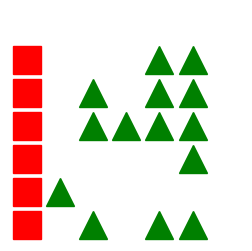

In [9]:
forest = create_forest(6,0.5)
fig = plt.figure(figsize=(3,3))
plotgrid(forest)

### But let's explore some bits and pieces of this

In [4]:
def create_forest(N=50,f_trees_start=0.5):
    '''
    Creates the initial game board.
    Inputs:
        board_size: length of one edge of the board
        f_trees_start: probability that a given cell is a tree
                       (effectively the tree density)

    Outputs a 2D numpy array with values set to either 0, 1, or 2
        (empty, tree, or fire)
    '''
    # all cells initialized to 'empty' (0) by default; board is defined to be N x N
    game_board = np.zeros((N,N))
    print("the empty board:\n",game_board)
    print("\n N_rows:",game_board.shape[0], "N_columns::", game_board.shape[1])
    
    # loop over all rows and columns on the board and roll the dice;
    # if the random number is less than f_trees_start, make it a tree.
    for i in range(game_board.shape[0]): # .shape[0] gives us number of rows
        for j in range(game_board.shape[1]): # .shape[1] gives us the number of columns
            if random.random() <= f_trees_start:
                game_board[i,j] = 1

    # set the whole left edge of the board on fire.
    # This means all rows for the first column, should be set to 2
    game_board[:,0] = 2
    print("\n the fully set up board:\n",game_board)
    
    return game_board

In [5]:
forest = create_forest(6,0.5)


the empty board:
 [[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]

 N_rows: 6 N_columns:: 6

 the fully set up board:
 [[2. 0. 0. 1. 1. 1.]
 [2. 1. 0. 0. 0. 0.]
 [2. 1. 1. 1. 0. 0.]
 [2. 1. 1. 1. 0. 0.]
 [2. 0. 1. 1. 1. 0.]
 [2. 0. 1. 1. 0. 0.]]


In [33]:
# function plotgrid() takes in a 2D array and uses matplotlib to make a plot.
# this function returns no values!

def plotgrid(myarray):
    
    # first create two vectors based on the x and y sizes of the grid
    x_range = np.linspace(0, myarray.shape[1]-1, myarray.shape[1]) # x means horizontal!
    y_range = np.linspace(0, myarray.shape[0]-1, myarray.shape[0]) # y means vertical!
    
    # use the numpy meshgrid function to create two matrices 
    # of the same size as myarray with x and y indexes
    x_indexes, y_indexes = np.meshgrid(x_range, y_range) 
    print("\n x from meshgrid:\n",x_indexes)
    print("\n y from meshgrid:\n",y_indexes)

    print("\n myarray:\n", myarray)
    print("\n myarray == 1:\n", myarray == 1)

    # make a list of all the x and y indexes that are either squares or triangles.
    # the notation below is relatively new to us; it means that when myarray==(value),
    # only record those values. 
    tr_x = x_indexes[myarray == 1]; 
    tr_y = y_indexes[myarray == 1];
    sq_x = x_indexes[myarray == 2]; 
    sq_y = y_indexes[myarray == 2];
    
    print("\n tr_x:\n", tr_x)
    
    # plot the squares and triangles.  make the size of the polygons 
    # larger than the default so they're easy to see!
    # Note: we have to reverse the y values to make sure it plots with the right orientation
    plt.plot(tr_x,  myarray.shape[0] - tr_y - 1, '^g',markersize=20)
    plt.plot(sq_x,  myarray.shape[0] - sq_y - 1, 'rs',markersize=20)
    
    # What if we didn't do that "reversing" part with the .shape and such for the y values?
    #plt.plot(tr_x,  tr_y, '^g',markersize=20)
    #plt.plot(sq_x,  sq_y, 'rs',markersize=20)
    
    # Set the x and y limits to include half a space overlap so we don't cut off the shapes
    plt.ylim([-0.5,myarray.shape[0] + 0.5]) 
    plt.xlim([-0.5,myarray.shape[1] + 0.5])
    
    # Turn the axes off
    plt.axis('off')


 x from meshgrid:
 [[0. 1. 2. 3. 4. 5.]
 [0. 1. 2. 3. 4. 5.]
 [0. 1. 2. 3. 4. 5.]
 [0. 1. 2. 3. 4. 5.]
 [0. 1. 2. 3. 4. 5.]
 [0. 1. 2. 3. 4. 5.]]

 y from meshgrid:
 [[0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 1.]
 [2. 2. 2. 2. 2. 2.]
 [3. 3. 3. 3. 3. 3.]
 [4. 4. 4. 4. 4. 4.]
 [5. 5. 5. 5. 5. 5.]]

 myarray:
 [[2. 0. 0. 1. 1. 1.]
 [2. 1. 0. 0. 0. 0.]
 [2. 1. 1. 1. 0. 0.]
 [2. 1. 1. 1. 0. 0.]
 [2. 0. 1. 1. 1. 0.]
 [2. 0. 1. 1. 0. 0.]]

 myarray == 1:
 [[False False False  True  True  True]
 [False  True False False False False]
 [False  True  True  True False False]
 [False  True  True  True False False]
 [False False  True  True  True False]
 [False False  True  True False False]]

 trx:
 [3. 4. 5. 1. 1. 2. 3. 1. 2. 3. 2. 3. 4. 2. 3.]


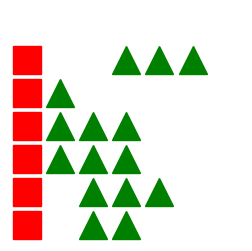

In [32]:
fig = plt.figure(figsize=(3,3))
plotgrid(forest)

## Goals for today
* Continue manipulating 2D NumPy arrays to store data and build models
* Lay the ground work for the forest fire model.
    * Need to make sure we have functional tools for setting up and visualizing the model
    * Need to create a function that can advance the model **one timestep forward in time**.
        * Your functions `onBoard` and `getNeighborValues` from last class will be useful!

## Looking forward - Day 19 PCA: Continuing work work with NumPy arrays, but in a new context.

* Learn a bit about voting theory
* Use NumPy as a way of storing votes and determining election outcomes